In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)



import warnings
warnings.filterwarnings("ignore")


**Load Dataset**

In [54]:
train = pd.read_csv("/kaggle/input/playground-series-s5e12/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")

train.head()


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


**Dataset structure + types**

In [55]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.info()
train.describe(include="all").T.head(25)
print(train.columns.tolist())

Train shape: (700000, 26)
Test shape: (300000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        70000

**Missing values + duplicates**

In [56]:
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test  = test.isnull().sum().sort_values(ascending=False)

print("Missing (train) top 10:\n", missing_train.head(10))
print("\nMissing (test) top 10:\n", missing_test.head(10))

print("\nDuplicates (train):", train.duplicated().sum())
print("Duplicates (test) :", test.duplicated().sum())


Missing (train) top 10:
 id                         0
age                        0
cardiovascular_history     0
hypertension_history       0
family_history_diabetes    0
employment_status          0
smoking_status             0
income_level               0
education_level            0
ethnicity                  0
dtype: int64

Missing (test) top 10:
 id                         0
hdl_cholesterol            0
hypertension_history       0
family_history_diabetes    0
employment_status          0
smoking_status             0
income_level               0
education_level            0
ethnicity                  0
gender                     0
dtype: int64

Duplicates (train): 0
Duplicates (test) : 0


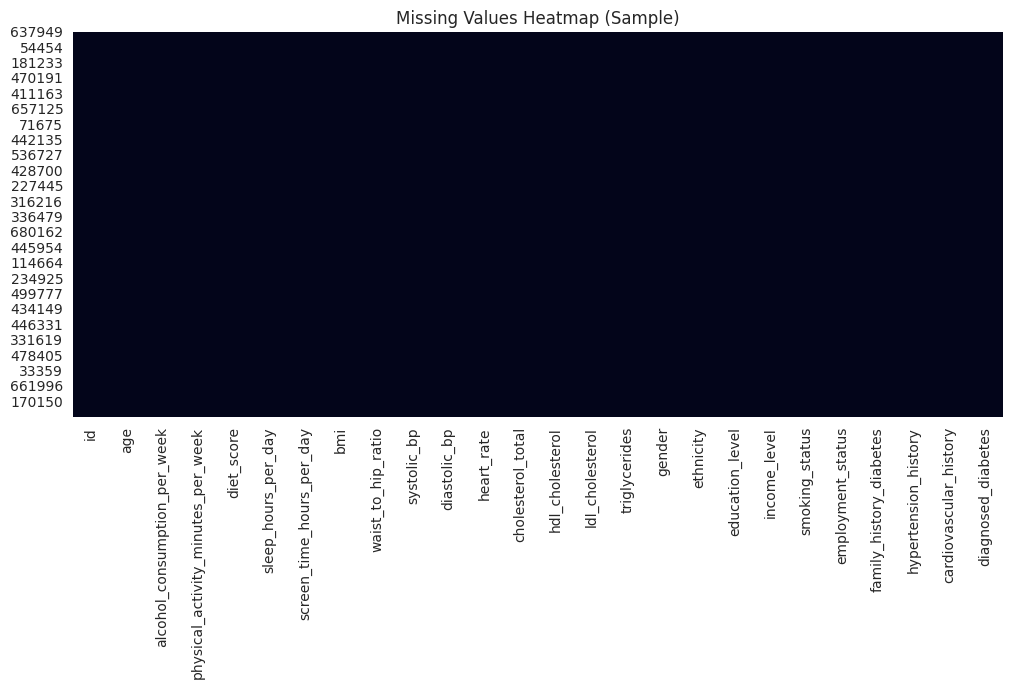

In [57]:
sample = train.sample(200, random_state=42)
plt.figure(figsize=(12,5))
sns.heatmap(sample.isnull(), cbar=False)
plt.title("Missing Values Heatmap (Sample)")
plt.show()

**Identify feature types (DO NOT encode here)**

In [58]:
TARGET = "diagnosed_diabetes"
ID_COL = "id"

feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]

cat_cols = train[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print("Total features:", len(feature_cols))
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))
print("\nCategorical columns:", cat_cols)


Total features: 24
Numerical: 18
Categorical: 6

Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


**Target distribution (class imbalance)**

Class counts:
 diagnosed_diabetes
1    436307
0    263693
Name: count, dtype: int64

Class %:
 diagnosed_diabetes
1    62.33
0    37.67
Name: proportion, dtype: float64


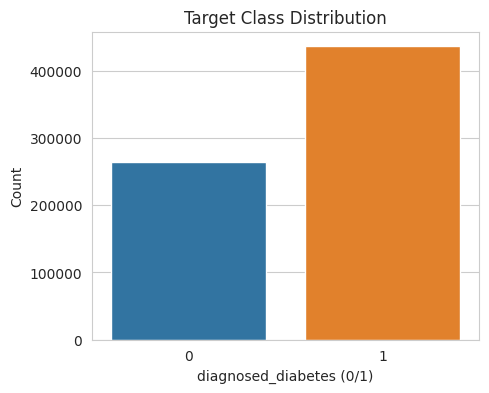

In [59]:
y = train[TARGET].astype(int)

print("Class counts:\n", y.value_counts())
print("\nClass %:\n", (y.value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("diagnosed_diabetes (0/1)")
plt.ylabel("Count")
plt.show()


**Numerical distributions + outliers**

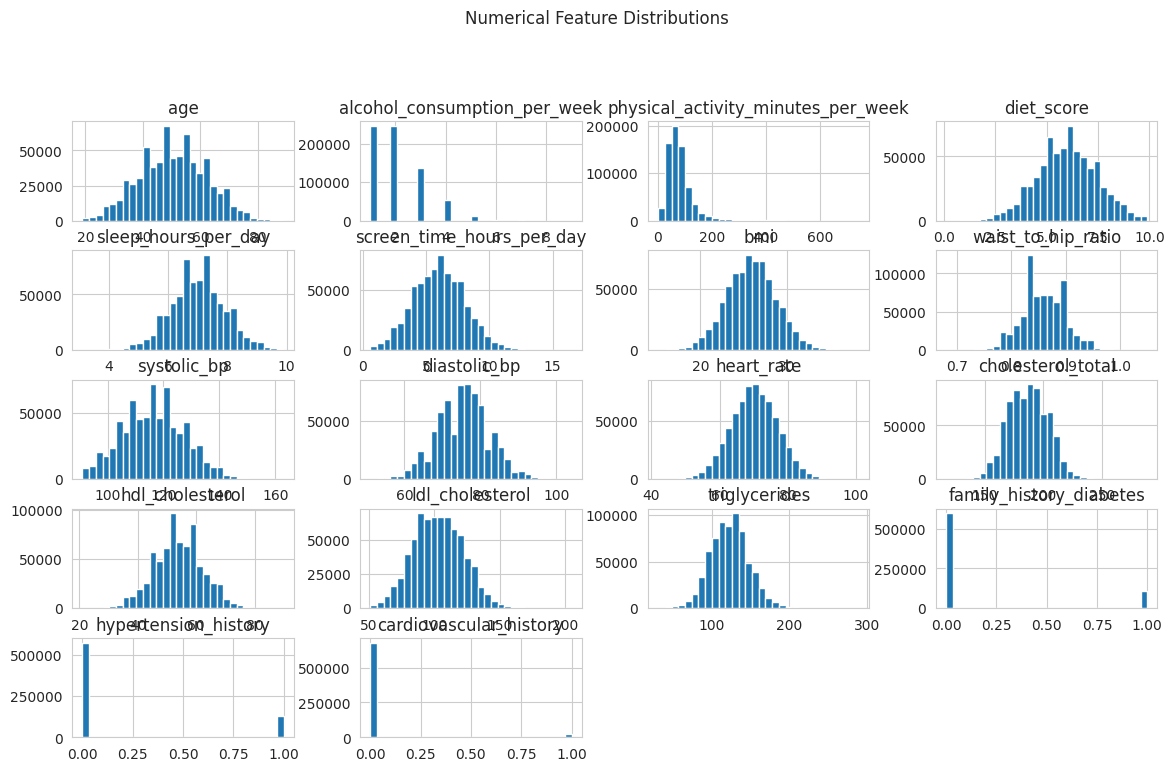

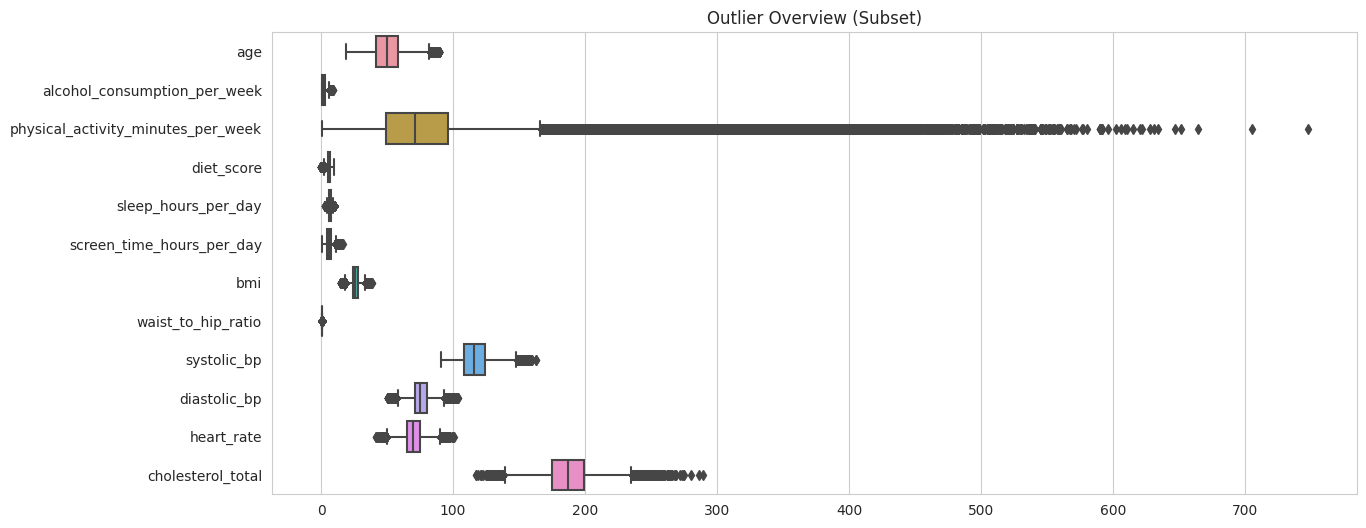

In [60]:
train[num_cols].hist(bins=30, figsize=(14,8))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.show()

subset_num = num_cols[:12]  # keep readable
plt.figure(figsize=(14,6))
sns.boxplot(data=train[subset_num], orient="h")
plt.title("Outlier Overview (Subset)")
plt.show()


**Categorical distributions (value counts)**

In [61]:
for c in cat_cols:
    print(f"\n{c} top categories:")
    print(train[c].value_counts().head(10))



gender top categories:
gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64

ethnicity top categories:
ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64

education_level top categories:
education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64

income_level top categories:
income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Low              85803
High             17234
Name: count, dtype: int64

smoking_status top categories:
smoking_status
Never      494448
Current    103363
Former     102189
Name: count, dtype: int64

employment_status top categories:
employment_status
Employed      516170
Retired       115735
Unemployed     49787
Student        18308
Name: count, dtype: int64


**Correlation (numerical only)**

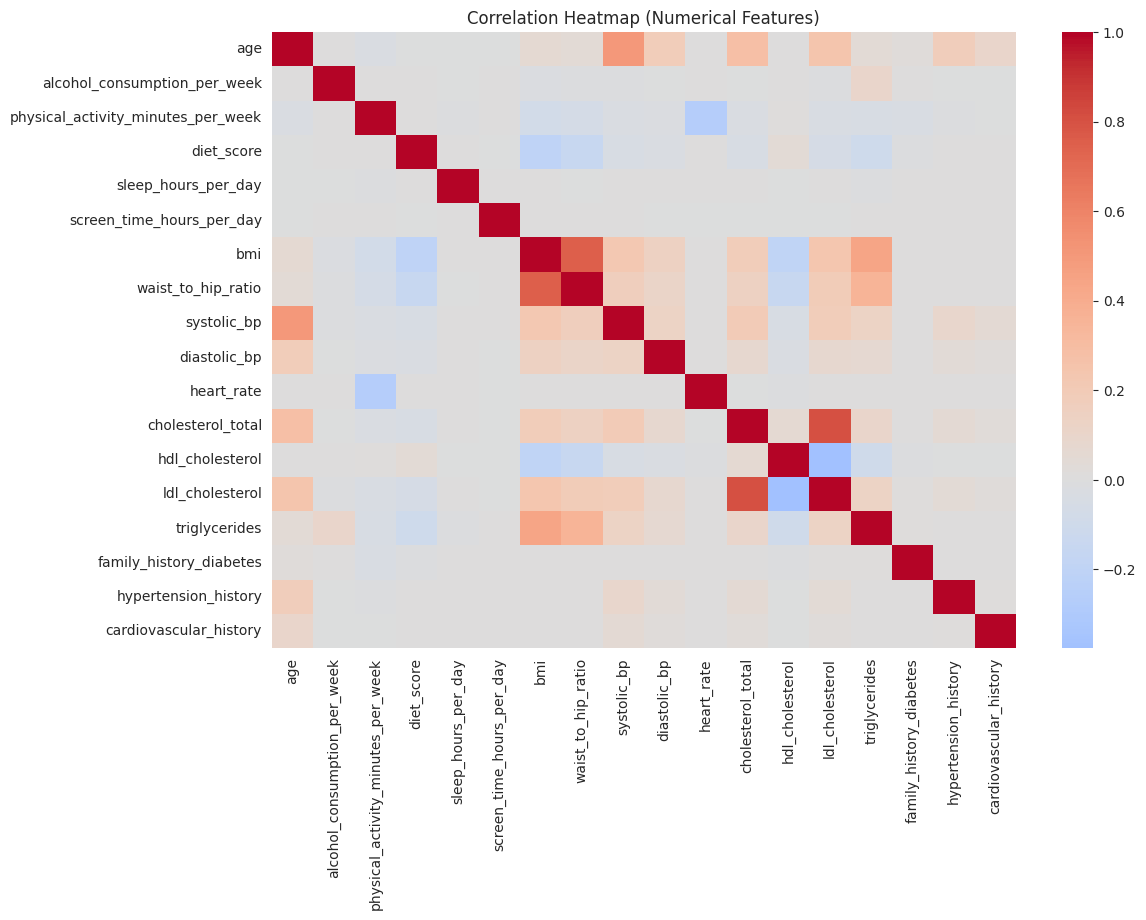

Top correlations with target:
 family_history_diabetes    0.211064
age                        0.161162
systolic_bp                0.107132
bmi                        0.105580
ldl_cholesterol            0.102771
triglycerides              0.090635
cholesterol_total          0.088112
waist_to_hip_ratio         0.081050
diastolic_bp               0.036271
hypertension_history       0.029979
dtype: float64


In [62]:
corr = train[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

corr_with_target = train[num_cols].corrwith(train[TARGET]).sort_values(ascending=False)
print("Top correlations with target:\n", corr_with_target.head(10))


**Mutual Information**

In [ ]:
X_mi = train[feature_cols].copy()

for c in cat_cols:
    le = LabelEncoder()
    X_mi[c] = le.fit_transform(X_mi[c].astype(str))

mi = mutual_info_classif(X_mi, y, random_state=42)
mi_df = pd.DataFrame({"Feature": feature_cols, "MI": mi}).sort_values("MI", ascending=False)

mi_df.head(15)


In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=mi_df.head(15), x="MI", y="Feature")
plt.title("Top 15 Mutual Information Features")
plt.show()


In [ ]:
top_features = mi_df["Feature"].head(6).tolist()
num_top = [f for f in top_features if f in num_cols]
cat_top = [f for f in top_features if f in cat_cols]

for f in num_top[:4]:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=train[TARGET], y=train[f])
    plt.title(f"{f} vs {TARGET}")
    plt.xlabel(TARGET)
    plt.ylabel(f)
    plt.show()

for f in cat_top[:2]:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train, x=f, hue=TARGET)
    plt.title(f"{f} by {TARGET}")
    plt.xticks(rotation=45)
    plt.show()


**Train vs Test shift (KS ranking + only top 3 plots)**

In [ ]:
ks_rows = []
for c in num_cols:
    stat, p = ks_2samp(train[c], test[c])
    ks_rows.append((c, stat, p))

ks_df = pd.DataFrame(ks_rows, columns=["Feature", "KS_Statistic", "p_value"]).sort_values("KS_Statistic", ascending=False)
ks_df.head(15)


In [ ]:
top_drift = ks_df["Feature"].head(3).tolist()
for c in top_drift:
    plt.figure(figsize=(6,4))
    sns.kdeplot(train[c], label="Train")
    sns.kdeplot(test[c], label="Test")
    plt.title(f"Train vs Test Distribution: {c}")
    plt.legend()
    plt.show()


**EDA-driven decisions (this is where EDA ends)**

In [ ]:
decisions = [
    "ID column is removed from modeling.",
    "Class imbalance exists → stratified splitting and recall-focused evaluation are used.",
    "Non-linear relationships exist (Mutual Information) → Random Forest and XGBoost are justified.",
    "Scaling is required for Logistic Regression; not required for RF/XGBoost.",
    "Outliers exist but tree ensembles are robust; values retained."
]
for i, d in enumerate(decisions, 1):
    print(f"{i}. {d}")


**MODELING + EVALUATION**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, balanced_accuracy_score, matthews_corrcoef,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.metrics import brier_score_loss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


**Prepare X, y (no leakage)**

In [ ]:
TARGET = "diagnosed_diabetes"
ID_COL = "id"

X = train.drop(columns=[TARGET, ID_COL])
y = train[TARGET].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Train:", X_train.shape, "Valid:", X_valid.shape)
print("Categorical:", len(cat_cols), "Numerical:", len(num_cols))


**Prosessing Pipeline**

In [ ]:
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_noscale = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer([
    ("num", numeric_scaled, num_cols),
    ("cat", categorical, cat_cols)
])

preprocess_noscale = ColumnTransformer([
    ("num", numeric_noscale, num_cols),
    ("cat", categorical, cat_cols)
]) 

**Build 3 models (LR, RF, XGBoost)**

In [ ]:
lr_pipeline = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocess", preprocess_noscale),
    ("model", RandomForestClassifier(
        n_estimators=300, max_depth=12, n_jobs=-1,
        random_state=42, class_weight="balanced_subsample"
    ))
])

# helpful for imbalance in XGBoost
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos

xgb_pipeline = Pipeline([
    ("preprocess", preprocess_noscale),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])


In [ ]:
lr_pipeline.fit(X_train, y_train)

In [ ]:
rf_pipeline.fit(X_train, y_train)

In [ ]:
xgb_pipeline.fit(X_train, y_train)

**Evaluation function**

In [ ]:
def evaluate_model(name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else 0.0

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_val, y_pred),
        "Precision(PPV)": precision_score(y_val, y_pred),
        "Recall(Sensitivity)": recall_score(y_val, y_pred),
        "Specificity": specificity,
        "NPV": npv,
        "F1": f1_score(y_val, y_pred),
        "ROC_AUC": roc_auc_score(y_val, y_proba),
        "PR_AUC": average_precision_score(y_val, y_proba),
        "LogLoss": log_loss(y_val, y_proba),
        "Brier": brier_score_loss(y_val, y_proba),
        "MCC": matthews_corrcoef(y_val, y_pred),
        "FPR": fp / (fp + tn) if (fp + tn) else 0.0,
        "FNR": fn / (fn + tp) if (fn + tp) else 0.0
    }


**Baseline Comparison Table**

In [ ]:
baseline_results = []
baseline_results.append(evaluate_model("Logistic Regression", lr_pipeline, X_valid, y_valid))
baseline_results.append(evaluate_model("Random Forest", rf_pipeline, X_valid, y_valid))
baseline_results.append(evaluate_model("XGBoost", xgb_pipeline, X_valid, y_valid))

baseline_df = pd.DataFrame(baseline_results).sort_values("ROC_AUC", ascending=False)
baseline_df


**Baseline ROC + PR Curves**

In [ ]:
plt.figure()
RocCurveDisplay.from_estimator(lr_pipeline, X_valid, y_valid)
RocCurveDisplay.from_estimator(rf_pipeline, X_valid, y_valid)
RocCurveDisplay.from_estimator(xgb_pipeline, X_valid, y_valid)
plt.title("ROC Curves (Validation) — Baseline")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_valid, y_valid)
PrecisionRecallDisplay.from_estimator(rf_pipeline, X_valid, y_valid)
PrecisionRecallDisplay.from_estimator(xgb_pipeline, X_valid, y_valid)
plt.title("Precision–Recall Curves (Validation) — Baseline")
plt.show()


**HYPERPARAMETER TUNING**

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


**Tune Random Forest**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, None],
    "model__max_features": ["sqrt"]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=2,            # only 2 candidates
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)


In [ ]:
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)


**Tune XGBoost**

In [ ]:
xgb_params = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 0.5],
    "model__reg_lambda": [1.0, 1.5, 2.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)


**RE-EVALUATION**

In [ ]:
tuned_results = []
tuned_results.append(evaluate_model("Logistic Regression", lr_pipeline, X_valid, y_valid))
tuned_results.append(evaluate_model("Random Forest (Tuned)", best_rf, X_valid, y_valid))
tuned_results.append(evaluate_model("XGBoost (Baseline)", best_xgb, X_valid, y_valid))

results_df = pd.DataFrame(tuned_results).sort_values("ROC_AUC", ascending=False)
results_df


**Tuned ROC + PR Curves**

In [ ]:
plt.figure()
RocCurveDisplay.from_estimator(lr_pipeline, X_valid, y_valid)
RocCurveDisplay.from_estimator(best_rf, X_valid, y_valid)
RocCurveDisplay.from_estimator(best_xgb, X_valid, y_valid)
plt.title("ROC Curves (Validation) — Tuned Models")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_valid, y_valid)
PrecisionRecallDisplay.from_estimator(best_rf, X_valid, y_valid)
PrecisionRecallDisplay.from_estimator(best_xgb, X_valid, y_valid)
plt.title("Precision–Recall Curves (Validation) — Tuned Models")
plt.show()


In [ ]:
tuned_results.append(evaluate_model("XGBoost (Tuned)", best_xgb, X_valid, y_valid))


In [ ]:
print(results_df["Model"].tolist())


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Selected best model:", best_model_name)


In [ ]:
best_model_map = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "Random Forest (Tuned)": best_rf if "best_rf" in globals() else rf_pipeline,
    "XGBoost": xgb_pipeline,
    "XGBoost (Baseline)": xgb_pipeline,
    "XGBoost (Tuned)": best_xgb if "best_xgb" in globals() else xgb_pipeline,
}

best_model = best_model_map[best_model_name]
print("Using model object for:", best_model_name)


In [ ]:
tuned_results = []

tuned_results.append(evaluate_model("Logistic Regression", lr_pipeline, X_valid, y_valid))
tuned_results.append(evaluate_model("Random Forest (Tuned)", best_rf, X_valid, y_valid))

# If you have best_xgb, use tuned. If not, use baseline.
if "best_xgb" in globals():
    tuned_results.append(evaluate_model("XGBoost (Tuned)", best_xgb, X_valid, y_valid))
else:
    tuned_results.append(evaluate_model("XGBoost (Baseline)", xgb_pipeline, X_valid, y_valid))

results_df = pd.DataFrame(tuned_results).sort_values("ROC_AUC", ascending=False)
print(results_df["Model"].tolist())
results_df


**Select best model and save for deployment**

In [ ]:
import os, json, joblib
import pandas as pd

best_model_name = results_df.iloc[0]["Model"]
print("Selected best model:", best_model_name)

best_model_map = {
    "Logistic Regression": lr_pipeline,
    "Random Forest (Tuned)": best_rf,
    "XGBoost (Baseline)": xgb_pipeline,
    "XGBoost (Tuned)": best_xgb if "best_xgb" in globals() else xgb_pipeline,
}

best_model = best_model_map[best_model_name]

X_full = pd.concat([X_train, X_valid], axis=0)
y_full = pd.concat([y_train, y_valid], axis=0)
best_model.fit(X_full, y_full)

os.makedirs("deploy_artifacts", exist_ok=True)
joblib.dump(best_model, "deploy_artifacts/final_diabetes_model.joblib")

with open("deploy_artifacts/feature_columns.json", "w") as f:
    json.dump(X.columns.tolist(), f, indent=2)

print("Saved deploy_artifacts/final_diabetes_model.joblib")
print("Saved deploy_artifacts/feature_columns.json")


In [ ]:
test_ids = test["id"]
preds = best_model.predict(test)
# or if Kaggle expects probabilities:
# preds = best_model.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    "id": test_ids,
    "Outcome": preds
})

submission.to_csv("submission.csv", index=False)


In [ ]:
import pickle

# Assuming your trained model is named 'model'
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)
